# Upbit Basic Chart

티커, 시작 날짜, 끝 날짜, 분봉 간격을 입력하면 업비트 OHLCV 데이터를 가져와 캔들 차트와 거래량을 표시합니다.
원하면 `SHOW_RSI`를 `True`로 두고 RSI 30/70 기준선도 함께 볼 수 있습니다.


In [5]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
import pyupbit

ROOT_DIR = Path.cwd().resolve().parent if Path.cwd().name == 'backtesting' else Path.cwd().resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

plt.style.use('ggplot')
pd.set_option('display.max_rows', 10)


In [6]:
TICKER = 'KRW-BTC'  # 업비트 마켓 티커
START_DATE = '2026-04-01 00:00:00'  # 차트에 표시할 시작 시각
END_DATE = '2026-05-08 00:00:00'  # 차트에 표시할 종료 시각
INTERVAL = 'minute60'  # 캔들 간격: minute1, minute5, minute15, minute60, day 등
REQUEST_COUNT = 200  # 업비트 API를 한 번 호출할 때 가져올 최대 캔들 수

SHOW_PRICE = True  # 가격 캔들 패널 표시 여부
SHOW_PRICE_MA5 = False  # 가격 패널 위 5기간 이동평균선 표시 여부
SHOW_PRICE_MA20 = False  # 가격 패널 위 20기간 이동평균선 표시 여부
SHOW_PRICE_MA60 = False  # 가격 패널 위 60기간 이동평균선 표시 여부
SHOW_BOLLINGER_BANDS = True  # 볼린저 밴드 표시 여부
SHOW_PRICE_LOWER_MARKERS = True  # 가격 패널에 과매도 점 표시 여부
SHOW_PRICE_UPPER_MARKERS = True  # 가격 패널에 과매수 점 표시 여부
SHOW_PRICE_MARKER_COUNTS = True  # 가격 패널 우측 상단 점 개수 표시 여부
SHOW_PRICE_GOLDEN_CROSS_MARKERS = False  # 가격 패널에 골든크로스 점 표시 여부
SHOW_PRICE_DEAD_CROSS_MARKERS = False  # 가격 패널에 데드크로스 점 표시 여부
BOLLINGER_PERIOD = 20  # 볼린저 밴드 중심선 기간
BOLLINGER_STD_MULTIPLIER = 2.0  # 볼린저 밴드 표준편차 배수

SHOW_MA_PANEL = True  # 이동평균선 전용 패널 표시 여부
SHOW_MA_PANEL_MA5 = True  # MA 패널의 5기간 이동평균선 표시 여부
SHOW_MA_PANEL_MA20 = True  # MA 패널의 20기간 이동평균선 표시 여부
SHOW_MA_PANEL_MA60 = True  # MA 패널의 60기간 이동평균선 표시 여부
SHOW_MA_GOLDEN_CROSS_MARKERS = False  # MA 패널에 골든크로스 점 표시 여부
SHOW_MA_DEAD_CROSS_MARKERS = False  # MA 패널에 데드크로스 점 표시 여부
SHOW_MA_MARKER_COUNTS = True  # MA 패널 우측 상단 점 개수 표시 여부
MA5_PERIOD = 5  # 단기 이동평균선 기간
MA20_PERIOD = 20  # 중기 이동평균선 기간
MA60_PERIOD = 60  # 장기 이동평균선 기간

SHOW_RSI = True  # RSI 패널 표시 여부
SHOW_RSI_LOWER_LINE = True  # RSI 하단 기준선 표시 여부
SHOW_RSI_UPPER_LINE = True  # RSI 상단 기준선 표시 여부
SHOW_RSI_LOWER_MARKERS = True  # RSI가 하단 기준선 이하일 때 점 표시 여부
SHOW_RSI_UPPER_MARKERS = True  # RSI가 상단 기준선 이상일 때 점 표시 여부
SHOW_RSI_MARKER_COUNTS = True  # RSI 패널 우측 상단 점 개수 표시 여부
RSI_PERIOD = 14  # RSI 계산 기간
RSI_LOWER = 30  # RSI 과매도 기준선
RSI_UPPER = 70  # RSI 과매수 기준선

SHOW_PROFIT_PANEL = True  # RSI 기반 수익률 패널 표시 여부
PROFIT_TOTAL_SEED_KRW = 3000000  # 전략 전체에서 사용할 총 시드 금액
PROFIT_INITIAL_BUY_KRW = 1000000  # 첫 매수에 사용할 금액
PROFIT_DCA_KRW = 1000000  # 보유 중 추가 매수(물타기) 금액
PROFIT_SELL_RATIO = 1.0  # 일반 매도 신호가 나왔을 때 매도할 비율 (0.5 = 50%, 1.0 = 100%)
PROFIT_STOP_LOSS_SELL_RATIO = 1.0  # 손절 신호가 나왔을 때 매도할 비율
PROFIT_FEE_RATE = 0.0005  # 매수/매도 각각 적용할 수수료율
PROFIT_STOP_LOSS_PCT = 3.0  # 평균 매수가 대비 손절 퍼센트

SHOW_VOLUME = False  # 거래량 패널 표시 여부
SHOW_VOLUME_MA = False  # 거래량 이동평균선 표시 여부
VOLUME_MA_PERIOD = 20  # 거래량 이동평균선 기간

# RSI가 시작일부터 자연스럽게 보이도록 여유 캔들을 미리 가져옵니다.
RSI_LOOKBACK_CANDLES = max(RSI_PERIOD * 2, 30)


def interval_to_timedelta(interval: str) -> pd.Timedelta:
    if interval.startswith('minute'):
        return pd.Timedelta(minutes=int(interval.replace('minute', '')))
    if interval == 'day':
        return pd.Timedelta(days=1)
    if interval == 'week':
        return pd.Timedelta(weeks=1)
    raise ValueError(f'Unsupported interval: {interval}')


def fetch_ohlcv_range(
    ticker: str,
    start_date: str,
    end_date: str,
    interval: str = 'minute60',
    request_count: int = 200,
    lookback_candles: int = 0,
) -> pd.DataFrame:
    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date)
    if start_ts > end_ts:
        raise ValueError('START_DATE must be earlier than or equal to END_DATE.')

    step = interval_to_timedelta(interval)
    # 표시 시작일보다 더 앞에서부터 받아와야 RSI 초반값이 비지 않습니다.
    fetch_start_ts = start_ts - (step * lookback_candles)
    cursor = end_ts + step
    frames: list[pd.DataFrame] = []

    while True:
        df = pyupbit.get_ohlcv(
            ticker,
            interval=interval,
            count=request_count,
            to=cursor.strftime('%Y-%m-%d %H:%M:%S'),
        )
        if df is None or df.empty:
            break

        df = df.sort_index()
        frames.append(df)

        oldest = df.index.min()
        if oldest <= fetch_start_ts or len(df) < request_count:
            break

        cursor = oldest

    if not frames:
        raise ValueError(f'No OHLCV data returned for {ticker} ({interval}).')

    merged = pd.concat(frames).sort_index()
    merged = merged[~merged.index.duplicated(keep='last')]
    filtered = merged.loc[(merged.index >= fetch_start_ts) & (merged.index <= end_ts)].copy()

    if filtered.empty:
        raise ValueError('No candles found in the selected date range.')

    return filtered


def add_rsi(df: pd.DataFrame, period: int = 14) -> pd.DataFrame:
    result = df.copy()
    delta = result['close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, pd.NA)
    result['rsi'] = 100 - (100 / (1 + rs))
    return result


def add_moving_averages(
    df: pd.DataFrame,
    periods: dict[str, int],
) -> pd.DataFrame:
    result = df.copy()
    for column_name, period in periods.items():
        result[column_name] = result['close'].rolling(window=period, min_periods=period).mean()
    return result


def add_volume_indicators(
    df: pd.DataFrame,
    volume_ma_period: int,
) -> pd.DataFrame:
    result = df.copy()
    result['volume_ma'] = result['volume'].rolling(window=volume_ma_period, min_periods=volume_ma_period).mean()
    return result


def add_bollinger_bands(
    df: pd.DataFrame,
    period: int,
    std_multiplier: float,
) -> pd.DataFrame:
    result = df.copy()
    rolling_mean = result['close'].rolling(window=period, min_periods=period).mean()
    rolling_std = result['close'].rolling(window=period, min_periods=period).std()
    result['bb_mid'] = rolling_mean
    result['bb_upper'] = rolling_mean + (rolling_std * std_multiplier)
    result['bb_lower'] = rolling_mean - (rolling_std * std_multiplier)
    return result


def add_cross_signals(
    df: pd.DataFrame,
    short_column: str,
    long_column: str,
) -> pd.DataFrame:
    result = df.copy()
    diff = result[short_column] - result[long_column]
    prev_diff = diff.shift(1)
    valid = result[short_column].notna() & result[long_column].notna() & prev_diff.notna()
    result['golden_cross'] = valid & (prev_diff <= 0) & (diff > 0)
    result['dead_cross'] = valid & (prev_diff >= 0) & (diff < 0)
    return result


def simulate_rsi_profit_panel(
    chart_df: pd.DataFrame,
    total_seed_krw: float,
    initial_buy_krw: float,
    dca_krw: float,
    sell_ratio: float,
    stop_loss_sell_ratio: float,
    fee_rate: float,
    stop_loss_pct: float,
    rsi_lower: float,
    rsi_upper: float,
) -> tuple[pd.DataFrame, dict[str, float | int | str]]:
    result_df = chart_df.copy()
    result_df['profit_krw'] = pd.NA
    result_df['profit_pct'] = pd.NA
    result_df['strategy_event'] = ''
    sell_ratio = min(max(sell_ratio, 0.0), 1.0)
    stop_loss_sell_ratio = min(max(stop_loss_sell_ratio, 0.0), 1.0)

    cash_krw = total_seed_krw
    position_units = 0.0
    position_cost_krw = 0.0
    total_buy_krw = 0.0
    total_sell_krw = 0.0
    trade_count = 0
    avg_entry_price = None

    for idx, row in result_df.iterrows():
        close_price = float(row['close'])
        lower_signal = bool(row['rsi'] <= rsi_lower) if pd.notna(row['rsi']) else False
        upper_signal = bool(row['rsi'] >= rsi_upper) if pd.notna(row['rsi']) else False

        event = ''

        if position_units > 0 and avg_entry_price is not None:
            stop_price = avg_entry_price * (1 - (stop_loss_pct / 100))
            if close_price <= stop_price:
                units_to_sell = position_units * stop_loss_sell_ratio
                proceeds = units_to_sell * close_price * (1 - fee_rate)
                total_sell_krw += proceeds
                cash_krw += proceeds
                position_units -= units_to_sell
                position_cost_krw -= avg_entry_price * units_to_sell
                if position_units <= 0:
                    position_units = 0.0
                    position_cost_krw = 0.0
                    avg_entry_price = None
                else:
                    avg_entry_price = position_cost_krw / position_units
                trade_count += 1
                event = 'stop_loss'
            elif upper_signal:
                units_to_sell = position_units * sell_ratio
                proceeds = units_to_sell * close_price * (1 - fee_rate)
                total_sell_krw += proceeds
                cash_krw += proceeds
                position_units -= units_to_sell
                position_cost_krw -= avg_entry_price * units_to_sell
                if position_units <= 0:
                    position_units = 0.0
                    position_cost_krw = 0.0
                    avg_entry_price = None
                else:
                    avg_entry_price = position_cost_krw / position_units
                trade_count += 1
                event = 'sell'

        if lower_signal:
            buy_krw = initial_buy_krw if position_units == 0 else dca_krw
            buy_krw = min(buy_krw, cash_krw)
            if buy_krw > 0:
                units_bought = (buy_krw * (1 - fee_rate)) / close_price
                cash_krw -= buy_krw
                position_units += units_bought
                position_cost_krw += buy_krw
                total_buy_krw += buy_krw
                avg_entry_price = position_cost_krw / position_units if position_units > 0 else None
                event = 'buy' if event == '' else f'{event}+buy'

        position_value_krw = position_units * close_price
        final_value_krw = cash_krw + position_value_krw
        net_profit_krw = final_value_krw - total_seed_krw
        profit_pct = (net_profit_krw / total_seed_krw * 100) if total_seed_krw > 0 else 0.0

        result_df.at[idx, 'profit_krw'] = net_profit_krw
        result_df.at[idx, 'profit_pct'] = profit_pct
        result_df.at[idx, 'strategy_event'] = event

    open_position = position_units > 0
    summary = {
        'total_seed_krw': float(total_seed_krw),
        'initial_buy_krw': float(initial_buy_krw),
        'remaining_cash_krw': float(cash_krw),
        'total_buy_krw': float(total_buy_krw),
        'sell_ratio': float(sell_ratio),
        'stop_loss_sell_ratio': float(stop_loss_sell_ratio),
        'current_value_krw': float(position_units * float(result_df['close'].iloc[-1])) if len(result_df) > 0 else 0.0,
        'total_sell_krw': float(total_sell_krw),
        'net_profit_krw': float(result_df['profit_krw'].iloc[-1]) if len(result_df) > 0 and pd.notna(result_df['profit_krw'].iloc[-1]) else 0.0,
        'profit_pct': float(result_df['profit_pct'].iloc[-1]) if len(result_df) > 0 and pd.notna(result_df['profit_pct'].iloc[-1]) else 0.0,
        'final_value_krw': float(cash_krw + (position_units * float(result_df['close'].iloc[-1]))) if len(result_df) > 0 else float(cash_krw),
        'trade_count': int(trade_count),
        'open_position': 'Yes' if open_position else 'No',
    }
    return result_df, summary


def plot_candles(
    df: pd.DataFrame,
    ticker: str,
    interval: str,
    show_price: bool = True,
    show_price_ma5: bool = True,
    show_price_ma20: bool = True,
    show_price_ma60: bool = False,
    show_ma_panel_ma5: bool = True,
    show_ma_panel_ma20: bool = True,
    show_ma_panel_ma60: bool = False,
    show_bollinger_bands: bool = False,
    show_ma_panel: bool = False,
    show_rsi: bool = False,
    show_profit_panel: bool = False,
    show_volume: bool = True,
    show_volume_ma: bool = True,
    show_price_lower_markers: bool = True,
    show_price_upper_markers: bool = True,
    show_price_marker_counts: bool = True,
    show_price_golden_cross_markers: bool = False,
    show_price_dead_cross_markers: bool = False,
    show_rsi_lower_line: bool = True,
    show_rsi_upper_line: bool = True,
    show_rsi_lower_markers: bool = True,
    show_rsi_upper_markers: bool = True,
    show_rsi_marker_counts: bool = True,
    show_ma_golden_cross_markers: bool = False,
    show_ma_dead_cross_markers: bool = False,
    show_ma_marker_counts: bool = True,
    bollinger_period: int = 20,
    bollinger_std_multiplier: float = 2.0,
    profit_total_seed_krw: float = 3000000,
    profit_initial_buy_krw: float = 1000000,
    profit_dca_krw: float = 1000000,
    profit_sell_ratio: float = 1.0,
    profit_stop_loss_sell_ratio: float = 1.0,
    profit_fee_rate: float = 0.0005,
    profit_stop_loss_pct: float = 3.0,
    volume_ma_period: int = 20,
    ma5_period: int = 5,
    ma20_period: int = 20,
    ma60_period: int = 60,
    rsi_period: int = 14,
    rsi_lower: float = 30,
    rsi_upper: float = 70,
    display_start_date: str | None = None,
    display_end_date: str | None = None,
) -> None:
    if not any([show_price, show_ma_panel, show_rsi, show_profit_panel, show_volume]):
        raise ValueError('At least one of SHOW_PRICE, SHOW_MA_PANEL, SHOW_RSI, SHOW_PROFIT_PANEL, SHOW_VOLUME must be True.')

    # RSI와 이동평균선은 전체 구간에서 먼저 계산한 뒤, 실제 표시 범위만 마지막에 잘라냅니다.
    chart_df = add_rsi(df, period=rsi_period)
    chart_df = add_moving_averages(
        chart_df,
        {
            'ma5': ma5_period,
            'ma20': ma20_period,
            'ma60': ma60_period,
        },
    )
    chart_df = add_bollinger_bands(chart_df, period=bollinger_period, std_multiplier=bollinger_std_multiplier)
    chart_df = add_volume_indicators(chart_df, volume_ma_period=volume_ma_period)
    chart_df = add_cross_signals(chart_df, short_column='ma5', long_column='ma20').reset_index().rename(columns={'index': 'datetime'})

    if display_start_date is not None:
        chart_df = chart_df.loc[chart_df['datetime'] >= pd.Timestamp(display_start_date)]
    if display_end_date is not None:
        chart_df = chart_df.loc[chart_df['datetime'] <= pd.Timestamp(display_end_date)]
    if chart_df.empty:
        raise ValueError('No chart data left after applying the display date range.')

    # 날짜 필터 후 인덱스를 다시 0부터 맞춰야 x축 배열과 행 순서가 정확히 맞습니다.
    chart_df = chart_df.reset_index(drop=True)

    x = mdates.date2num(chart_df['datetime'].to_numpy())
    candle_width = max(0.0005, (x[1] - x[0]) * 0.7) if len(x) > 1 else 0.02

    lower_signal_points = chart_df.loc[chart_df['rsi'] <= rsi_lower]
    upper_signal_points = chart_df.loc[chart_df['rsi'] >= rsi_upper]
    golden_cross_points = chart_df.loc[chart_df['golden_cross']]
    dead_cross_points = chart_df.loc[chart_df['dead_cross']]
    profit_df, profit_summary = simulate_rsi_profit_panel(
        chart_df,
        total_seed_krw=profit_total_seed_krw,
        initial_buy_krw=profit_initial_buy_krw,
        dca_krw=profit_dca_krw,
        sell_ratio=profit_sell_ratio,
        stop_loss_sell_ratio=profit_stop_loss_sell_ratio,
        fee_rate=profit_fee_rate,
        stop_loss_pct=profit_stop_loss_pct,
        rsi_lower=rsi_lower,
        rsi_upper=rsi_upper,
    )

    panel_specs = []
    if show_price:
        panel_specs.append(('price', 3))
    if show_ma_panel:
        panel_specs.append(('ma', 1))
    if show_rsi:
        panel_specs.append(('rsi', 1))
    if show_profit_panel:
        panel_specs.append(('profit', 1))
    if show_volume:
        panel_specs.append(('volume', 1))

    fig, axes = plt.subplots(
        len(panel_specs),
        1,
        figsize=(16, 6 + len(panel_specs) * 1.5),
        sharex=True,
        gridspec_kw={'height_ratios': [ratio for _, ratio in panel_specs]},
    )

    if not isinstance(axes, (list, tuple)):
        axes = [axes] if getattr(axes, 'ndim', 0) == 0 else list(axes)

    axis_map = {name: axis for (name, _), axis in zip(panel_specs, axes)}
    ax_price = axis_map.get('price')
    ax_ma = axis_map.get('ma')
    ax_rsi = axis_map.get('rsi')
    ax_profit = axis_map.get('profit')
    ax_volume = axis_map.get('volume')

    for i, row in chart_df.iterrows():
        color = '#d62728' if row['close'] >= row['open'] else '#1f77b4'
        if ax_price is not None:
            ax_price.vlines(x[i], row['low'], row['high'], color=color, linewidth=1.0)
            body_bottom = min(row['open'], row['close'])
            body_height = abs(row['close'] - row['open'])
            if body_height == 0:
                body_height = max(row['close'] * 0.0005, 1e-6)
            ax_price.add_patch(
                Rectangle(
                    (x[i] - candle_width / 2, body_bottom),
                    candle_width,
                    body_height,
                    facecolor=color,
                    edgecolor=color,
                    alpha=0.85,
                )
            )
        if ax_volume is not None:
            ax_volume.bar(x[i], row['volume'], width=candle_width, color=color, alpha=0.35)

    if ax_price is not None:
        if show_price_ma5:
            ax_price.plot(chart_df['datetime'], chart_df['ma5'], color='#9467bd', linewidth=1.2, label=f'MA{ma5_period}')
        if show_price_ma20:
            ax_price.plot(chart_df['datetime'], chart_df['ma20'], color='#2ca02c', linewidth=1.2, label=f'MA{ma20_period}')
        if show_price_ma60:
            ax_price.plot(chart_df['datetime'], chart_df['ma60'], color='#8c564b', linewidth=1.2, label=f'MA{ma60_period}')
        if show_bollinger_bands:
            ax_price.plot(chart_df['datetime'], chart_df['bb_mid'], color='#7f7f7f', linewidth=1.0, linestyle='--', label=f'BB Mid {bollinger_period}')
            ax_price.plot(chart_df['datetime'], chart_df['bb_upper'], color='#17becf', linewidth=1.0, alpha=0.9, label='BB Upper')
            ax_price.plot(chart_df['datetime'], chart_df['bb_lower'], color='#17becf', linewidth=1.0, alpha=0.9, label='BB Lower')
        if show_price_lower_markers:
            ax_price.scatter(lower_signal_points['datetime'], lower_signal_points['close'], color='#1f77b4', s=18, zorder=3)
        if show_price_upper_markers:
            ax_price.scatter(upper_signal_points['datetime'], upper_signal_points['close'], color='#d62728', s=18, zorder=3)
        if show_price_golden_cross_markers:
            ax_price.scatter(golden_cross_points['datetime'], golden_cross_points['close'], color='#ffd700', s=26, zorder=4)
        if show_price_dead_cross_markers:
            ax_price.scatter(dead_cross_points['datetime'], dead_cross_points['close'], color='#111111', s=26, zorder=4)
        if show_price_marker_counts and (show_price_lower_markers or show_price_upper_markers or show_price_golden_cross_markers or show_price_dead_cross_markers):
            blue_count = len(lower_signal_points) if show_price_lower_markers else 0
            red_count = len(upper_signal_points) if show_price_upper_markers else 0
            gold_count = len(golden_cross_points) if show_price_golden_cross_markers else 0
            black_count = len(dead_cross_points) if show_price_dead_cross_markers else 0
            ax_price.text(
                0.995,
                0.98,
                f'Blue: {blue_count} | Red: {red_count} | Gold: {gold_count} | Black: {black_count}',
                transform=ax_price.transAxes,
                ha='right',
                va='top',
                fontsize=10,
                bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none'},
            )
        ax_price.set_title(f'{ticker} {interval} Chart')
        ax_price.set_ylabel('Price (KRW)')
        ax_price.grid(True, alpha=0.3)
        if show_price_ma5 or show_price_ma20 or show_price_ma60 or show_bollinger_bands:
            ax_price.legend(loc='upper left')

    if ax_ma is not None:
        if show_ma_panel_ma5:
            ax_ma.plot(chart_df['datetime'], chart_df['ma5'], color='#9467bd', linewidth=1.2, label=f'MA{ma5_period}')
        if show_ma_panel_ma20:
            ax_ma.plot(chart_df['datetime'], chart_df['ma20'], color='#2ca02c', linewidth=1.2, label=f'MA{ma20_period}')
        if show_ma_panel_ma60:
            ax_ma.plot(chart_df['datetime'], chart_df['ma60'], color='#8c564b', linewidth=1.2, label=f'MA{ma60_period}')
        if show_ma_golden_cross_markers:
            ax_ma.scatter(golden_cross_points['datetime'], golden_cross_points['ma5'], color='#ffd700', s=26, zorder=4, label='Golden Cross')
        if show_ma_dead_cross_markers:
            ax_ma.scatter(dead_cross_points['datetime'], dead_cross_points['ma5'], color='#111111', s=26, zorder=4, label='Dead Cross')
        if show_ma_marker_counts and (show_ma_golden_cross_markers or show_ma_dead_cross_markers):
            gold_count = len(golden_cross_points) if show_ma_golden_cross_markers else 0
            black_count = len(dead_cross_points) if show_ma_dead_cross_markers else 0
            ax_ma.text(
                0.995,
                0.98,
                f'Gold: {gold_count} | Black: {black_count}',
                transform=ax_ma.transAxes,
                ha='right',
                va='top',
                fontsize=10,
                bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none'},
            )
        ax_ma.set_ylabel('MA')
        ax_ma.grid(True, alpha=0.2)
        if show_ma_panel_ma5 or show_ma_panel_ma20 or show_ma_panel_ma60 or show_ma_golden_cross_markers or show_ma_dead_cross_markers:
            ax_ma.legend(loc='upper left')

    if ax_rsi is not None:
        ax_rsi.plot(chart_df['datetime'], chart_df['rsi'], color='#ff7f0e', linewidth=1.4)
        if show_rsi_lower_line:
            ax_rsi.axhline(rsi_lower, color='#2ca02c', linestyle='--', linewidth=1.0)
        if show_rsi_upper_line:
            ax_rsi.axhline(rsi_upper, color='#d62728', linestyle='--', linewidth=1.0)

        lower_points = lower_signal_points if show_rsi_lower_markers else chart_df.iloc[0:0]
        upper_points = upper_signal_points if show_rsi_upper_markers else chart_df.iloc[0:0]

        if show_rsi_lower_markers:
            ax_rsi.scatter(lower_points['datetime'], lower_points['rsi'], color='#1f77b4', s=18, zorder=3)

        if show_rsi_upper_markers:
            ax_rsi.scatter(upper_points['datetime'], upper_points['rsi'], color='#d62728', s=18, zorder=3)

        if show_rsi_marker_counts and (show_rsi_lower_markers or show_rsi_upper_markers):
            blue_count = len(lower_points) if show_rsi_lower_markers else 0
            red_count = len(upper_points) if show_rsi_upper_markers else 0
            ax_rsi.text(
                0.995,
                0.98,
                f'Blue: {blue_count} | Red: {red_count}',
                transform=ax_rsi.transAxes,
                ha='right',
                va='top',
                fontsize=10,
                bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none'},
            )

        ax_rsi.set_ylabel('RSI')
        ax_rsi.set_ylim(0, 100)
        ax_rsi.grid(True, alpha=0.2)

    if ax_profit is not None:
        ax_profit.plot(profit_df['datetime'], profit_df['profit_pct'], color='#2ca02c', linewidth=1.4, label='Profit %')
        buy_events = profit_df.loc[profit_df['strategy_event'].str.contains('buy', na=False)]
        sell_events = profit_df.loc[profit_df['strategy_event'].str.contains('sell', na=False)]
        stop_events = profit_df.loc[profit_df['strategy_event'].str.contains('stop_loss', na=False)]
        if not buy_events.empty:
            ax_profit.scatter(buy_events['datetime'], buy_events['profit_pct'], color='#1f77b4', s=18, zorder=3, label='Buy')
        if not sell_events.empty:
            ax_profit.scatter(sell_events['datetime'], sell_events['profit_pct'], color='#d62728', s=18, zorder=3, label='Sell')
        if not stop_events.empty:
            ax_profit.scatter(stop_events['datetime'], stop_events['profit_pct'], color='#111111', s=18, zorder=3, label='Stop')
        ax_profit.axhline(0, color='#7f7f7f', linestyle='--', linewidth=1.0)
        ax_profit.set_ylabel('Profit %')
        ax_profit.grid(True, alpha=0.2)
        profit_summary_text = (
            f"Seed: {profit_summary['total_seed_krw']:,.0f} | 1st Buy: {profit_summary['initial_buy_krw']:,.0f} | "
            f"Total Buy: {profit_summary['total_buy_krw']:,.0f} | Cash: {profit_summary['remaining_cash_krw']:,.0f} | Sell: {profit_summary['sell_ratio'] * 100:.0f}%\n"
            f"PnL: {profit_summary['profit_pct']:.2f}% | PnL KRW: {profit_summary['net_profit_krw']:,.0f} | "
            f"Final Value: {profit_summary['final_value_krw']:,.0f} | Trades: {profit_summary['trade_count']} | Open: {profit_summary['open_position']}"
        )
        ax_profit.text(
            0.995,
            1.10,
            profit_summary_text,
            transform=ax_profit.transAxes,
            ha='right',
            va='bottom',
            fontsize=9,
            linespacing=1.3,
            bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none'},
        )
        ax_profit.legend(loc='upper left')

    if ax_volume is not None:
        ax_volume.set_ylabel('Volume')
        if show_volume_ma:
            ax_volume.plot(chart_df['datetime'], chart_df['volume_ma'], color='#ff7f0e', linewidth=1.2, label=f'Vol MA{volume_ma_period}')
        ax_volume.grid(True, alpha=0.2)
        if show_volume_ma:
            ax_volume.legend(loc='upper left')

    bottom_axis = axes[-1]
    bottom_axis.set_xlabel('Datetime')
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    bottom_axis.xaxis.set_major_locator(locator)
    bottom_axis.xaxis.set_major_formatter(formatter)

    plt.tight_layout()
    plt.show()


,open,high,low,close,volume,value
2026-05-07 20:00:00,118858000.0,119141000.0,118800000.0,118841000.0,38.794900,4.614021e+09
2026-05-07 21:00:00,118870000.0,119193000.0,118837000.0,119138000.0,40.791206,4.855186e+09
2026-05-07 22:00:00,119139000.0,119155000.0,118200000.0,118552000.0,128.489332,1.523449e+10
2026-05-07 23:00:00,118525000.0,118620000.0,118000000.0,118048000.0,111.968604,1.323868e+10
2026-05-08 00:00:00,118050000.0,118196000.0,117580000.0,117763000.0,138.533816,1.633073e+10


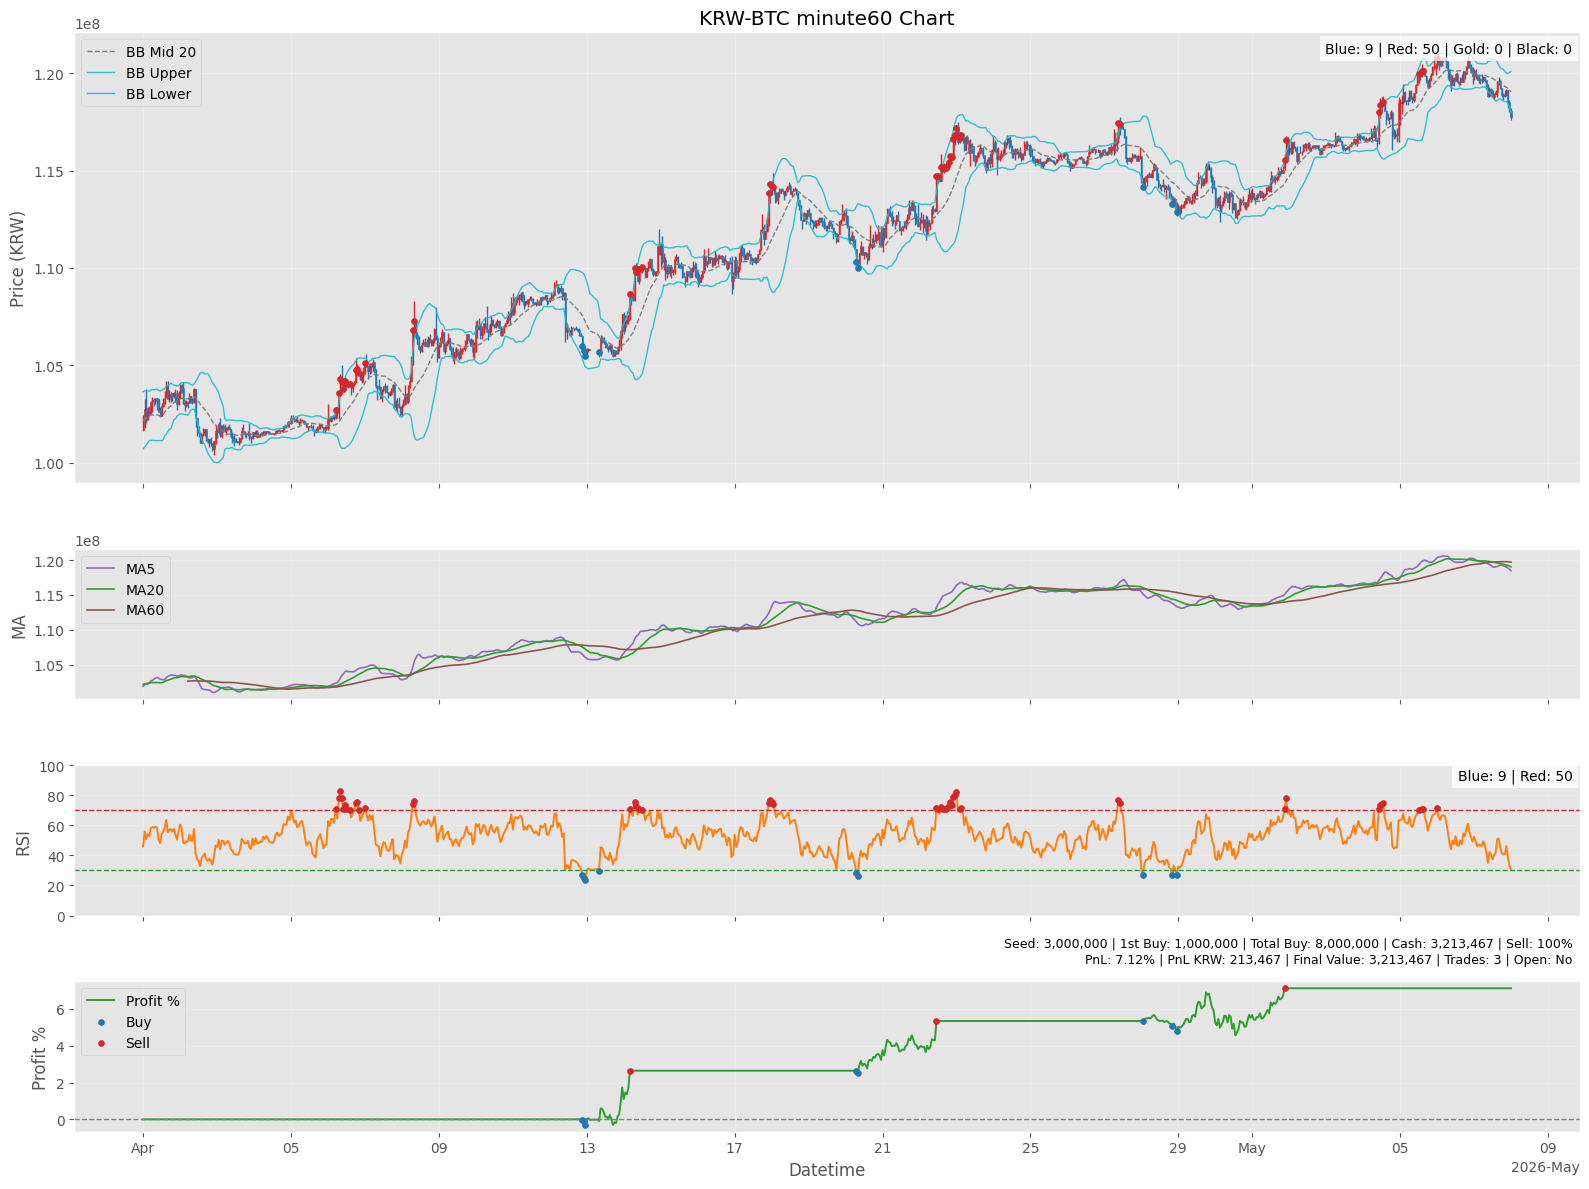

In [7]:
# RSI 계산용 여유 데이터를 포함해서 먼저 조회합니다.
ohlcv_df = fetch_ohlcv_range(
    ticker=TICKER,
    start_date=START_DATE,
    end_date=END_DATE,
    interval=INTERVAL,
    request_count=REQUEST_COUNT,
    lookback_candles=RSI_LOOKBACK_CANDLES if SHOW_RSI else 0,
)

# 표는 사용자가 요청한 실제 표시 구간만 보여줍니다.
display_df = ohlcv_df.loc[(ohlcv_df.index >= pd.Timestamp(START_DATE)) & (ohlcv_df.index <= pd.Timestamp(END_DATE))].copy()
display(display_df.tail())
plot_candles(
    ohlcv_df,
    ticker=TICKER,
    interval=INTERVAL,
    show_price=SHOW_PRICE,
    show_price_ma5=SHOW_PRICE_MA5 if SHOW_PRICE else False,
    show_price_ma20=SHOW_PRICE_MA20 if SHOW_PRICE else False,
    show_price_ma60=SHOW_PRICE_MA60 if SHOW_PRICE else False,
    show_ma_panel_ma5=SHOW_MA_PANEL_MA5 if SHOW_MA_PANEL else False,
    show_ma_panel_ma20=SHOW_MA_PANEL_MA20 if SHOW_MA_PANEL else False,
    show_ma_panel_ma60=SHOW_MA_PANEL_MA60 if SHOW_MA_PANEL else False,
    show_bollinger_bands=SHOW_BOLLINGER_BANDS if SHOW_PRICE else False,
    show_ma_panel=SHOW_MA_PANEL,
    show_rsi=SHOW_RSI,
    show_profit_panel=SHOW_PROFIT_PANEL,
    show_volume=SHOW_VOLUME,
    show_volume_ma=SHOW_VOLUME_MA if SHOW_VOLUME else False,
    show_price_lower_markers=SHOW_PRICE_LOWER_MARKERS if SHOW_PRICE else False,
    show_price_upper_markers=SHOW_PRICE_UPPER_MARKERS if SHOW_PRICE else False,
    show_price_marker_counts=SHOW_PRICE_MARKER_COUNTS if SHOW_PRICE else False,
    show_price_golden_cross_markers=SHOW_PRICE_GOLDEN_CROSS_MARKERS if SHOW_PRICE else False,
    show_price_dead_cross_markers=SHOW_PRICE_DEAD_CROSS_MARKERS if SHOW_PRICE else False,
    show_rsi_lower_line=SHOW_RSI_LOWER_LINE if SHOW_RSI else False,
    show_rsi_upper_line=SHOW_RSI_UPPER_LINE if SHOW_RSI else False,
    show_rsi_lower_markers=SHOW_RSI_LOWER_MARKERS if SHOW_RSI else False,
    show_rsi_upper_markers=SHOW_RSI_UPPER_MARKERS if SHOW_RSI else False,
    show_rsi_marker_counts=SHOW_RSI_MARKER_COUNTS if SHOW_RSI else False,
    show_ma_golden_cross_markers=SHOW_MA_GOLDEN_CROSS_MARKERS if SHOW_MA_PANEL else False,
    show_ma_dead_cross_markers=SHOW_MA_DEAD_CROSS_MARKERS if SHOW_MA_PANEL else False,
    show_ma_marker_counts=SHOW_MA_MARKER_COUNTS if SHOW_MA_PANEL else False,
    profit_total_seed_krw=PROFIT_TOTAL_SEED_KRW,
    profit_initial_buy_krw=PROFIT_INITIAL_BUY_KRW,
    profit_dca_krw=PROFIT_DCA_KRW,
    profit_sell_ratio=PROFIT_SELL_RATIO,
    profit_stop_loss_sell_ratio=PROFIT_STOP_LOSS_SELL_RATIO,
    profit_fee_rate=PROFIT_FEE_RATE,
    profit_stop_loss_pct=PROFIT_STOP_LOSS_PCT,
    bollinger_period=BOLLINGER_PERIOD,
    bollinger_std_multiplier=BOLLINGER_STD_MULTIPLIER,
    volume_ma_period=VOLUME_MA_PERIOD,
    ma5_period=MA5_PERIOD,
    ma20_period=MA20_PERIOD,
    ma60_period=MA60_PERIOD,
    rsi_period=RSI_PERIOD,
    rsi_lower=RSI_LOWER,
    rsi_upper=RSI_UPPER,
    display_start_date=START_DATE,
    display_end_date=END_DATE,
)



,value
ticker,KRW-BTC
interval,minute60
seed_krw,3000000.0
coin_max_money_krw,600000.0
first_enter_money_krw,60000.0
...,...
buy_count,6
sell_count,3
stop_count,0
trade_count,3


,datetime,event,price,rsi,revenue_rate,amount_krw
0,2026-04-13 00:00:00,BUY-NEW,105802000.0,30.121702,-0.050000,60000.000000
1,2026-04-13 09:00:00,BUY-WATER-1,106427000.0,45.385603,0.343620,30000.000000
2,2026-04-14 04:00:00,SELL-PROFIT-ALL,108648000.0,70.581497,2.437668,92147.804122
3,2026-04-20 09:00:00,BUY-NEW,110753000.0,38.313722,-0.050000,60000.000000
4,2026-04-22 11:00:00,SELL-PROFIT-ALL,114743000.0,71.484183,3.550810,62099.420703
5,2026-04-28 02:00:00,BUY-NEW,114525000.0,33.988272,-0.050000,60000.000000
6,2026-04-28 21:00:00,BUY-WATER-1,113541000.0,33.208526,-0.622514,30000.000000
7,2026-04-29 00:00:00,BUY-WATER-1,113151000.0,32.572367,-0.735398,30000.000000
8,2026-05-01 21:00:00,SELL-PROFIT-ALL,115567000.0,70.687832,1.384099,121600.088852


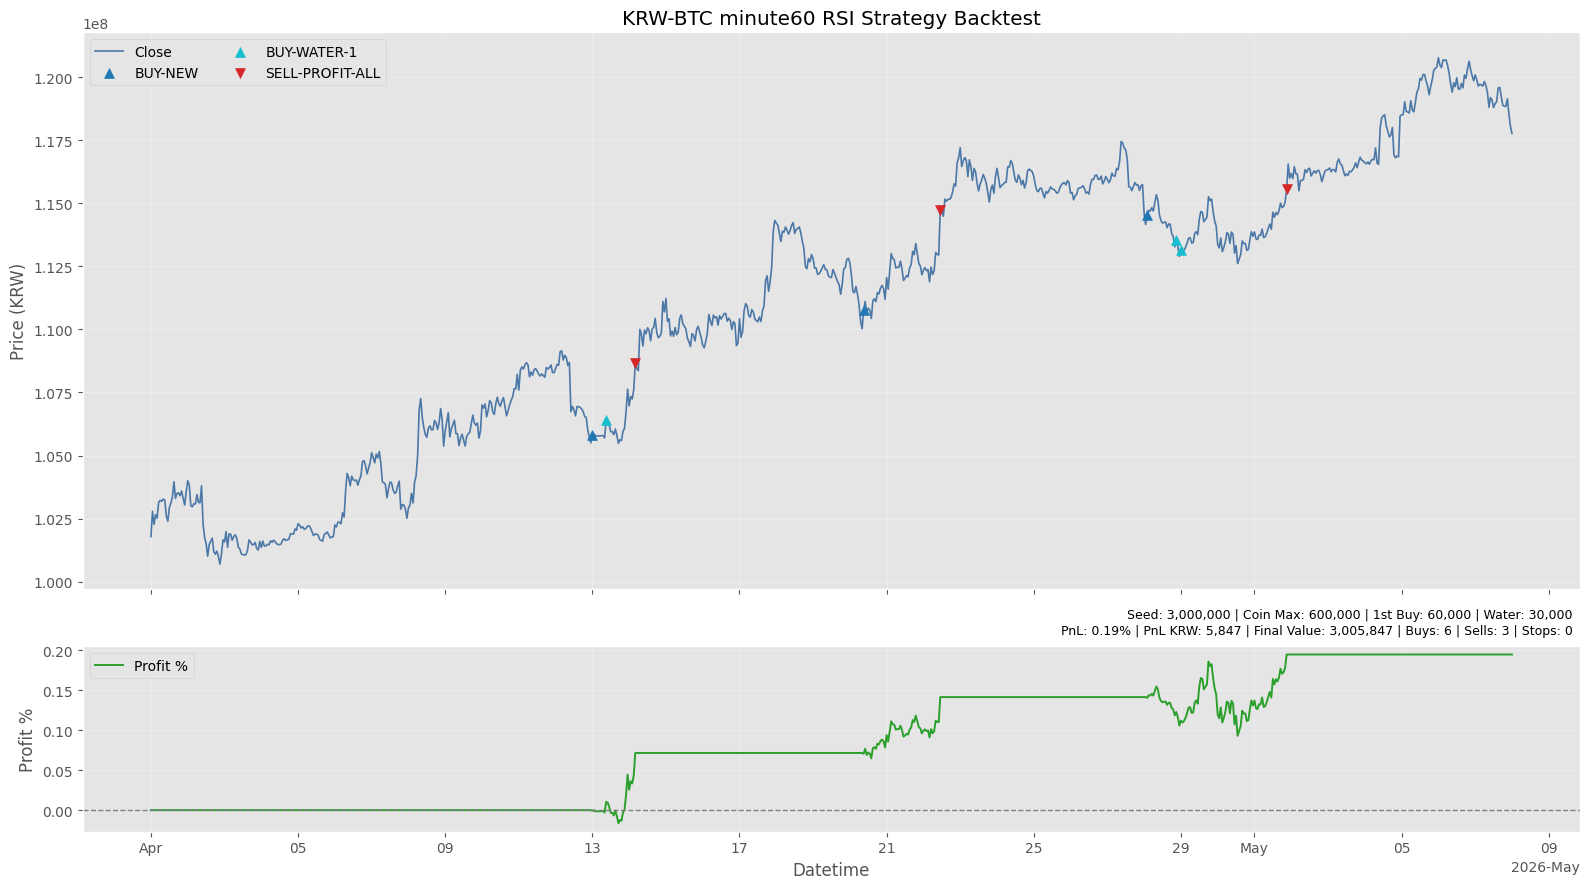

In [8]:
# RSI 전략 백테스트 설정
BACKTEST_TOTAL_SEED_KRW = 3_000_000  # 전체 시드
BACKTEST_MAX_COIN_CNT = 5  # 동시에 보유 가능한 최대 코인 수
BACKTEST_FIRST_RATE_PCT = 10.0  # 첫 진입 비중 (% of coinMaxMoney)
BACKTEST_WATER_RATE_PCT = 5.0  # 물타기 비중 (% of coinMaxMoney)
BACKTEST_PROFIT_RSI = 70.0  # 익절 RSI 기준
BACKTEST_PROFIT_MIN_PCT = 1.0  # 익절 최소 수익률
BACKTEST_WATER_LIMIT_PCT = 50.0  # 일반 물타기 허용 비중 상한
BACKTEST_WATER2_MIN_LOSS_PCT = -5.0  # 50% 초과 상태 추가 물타기 기준
BACKTEST_STOP_LOSS_PCT = -10.0  # 원화 부족 시 손절 기준 수익률
BACKTEST_PROFIT_FULL_SELL_BELOW_ALLOC_PCT = 25.0  # 이 비중 미만이면 전량 익절
BACKTEST_HALF_SELL_RATIO = 0.5  # 절반 매도 비율
BACKTEST_FEE_RATE = 0.0005  # 매수/매도 수수료율
BACKTEST_SHOW_PLOT = True  # 백테스트 그래프 표시 여부


def simulate_rsi_rebound_backtest(
    df: pd.DataFrame,
    total_seed_krw: float,
    max_coin_cnt: int,
    first_rate_pct: float,
    water_rate_pct: float,
    profit_rsi: float,
    profit_min_pct: float,
    water_limit_pct: float,
    water2_min_loss_pct: float,
    stop_loss_pct: float,
    profit_full_sell_below_alloc_pct: float,
    half_sell_ratio: float,
    fee_rate: float,
    rsi_period: int,
    rsi_lower: float,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, float | int | str]]:
    chart_df = add_rsi(df, period=rsi_period).reset_index().rename(columns={'index': 'datetime'})
    chart_df = chart_df.loc[
        (chart_df['datetime'] >= pd.Timestamp(START_DATE))
        & (chart_df['datetime'] <= pd.Timestamp(END_DATE))
    ].reset_index(drop=True)
    if chart_df.empty:
        raise ValueError('백테스트 대상 데이터가 없습니다.')

    chart_df['prev_rsi'] = chart_df['rsi'].shift(1)
    chart_df['profit_pct'] = 0.0
    chart_df['profit_krw'] = 0.0
    chart_df['equity_krw'] = 0.0
    chart_df['cash_krw'] = 0.0
    chart_df['holdings_value_krw'] = 0.0
    chart_df['invested_krw'] = 0.0
    chart_df['avg_entry_price'] = pd.NA
    chart_df['revenue_rate'] = 0.0
    chart_df['strategy_event'] = ''

    coin_max_money = total_seed_krw / max(max_coin_cnt, 1)
    first_enter_money = coin_max_money * (first_rate_pct / 100)
    water_enter_money = coin_max_money * (water_rate_pct / 100)

    cash_krw = total_seed_krw
    position_units = 0.0
    position_cost_krw = 0.0
    total_buy_krw = 0.0
    total_sell_krw = 0.0
    trade_count = 0
    buy_count = 0
    sell_count = 0
    stop_count = 0
    event_rows: list[dict[str, object]] = []

    def current_revenue_rate(close_price: float) -> float:
        if position_units <= 0 or position_cost_krw <= 0:
            return 0.0
        avg_price = position_cost_krw / position_units
        return ((close_price - avg_price) / avg_price) * 100

    for idx, row in chart_df.iterrows():
        close_price = float(row['close'])
        prev_rsi = row['prev_rsi']
        current_rsi = row['rsi']
        lower_cross = bool(pd.notna(prev_rsi) and pd.notna(current_rsi) and prev_rsi <= rsi_lower and current_rsi > rsi_lower)
        upper_signal = bool(pd.notna(current_rsi) and current_rsi >= profit_rsi)
        revenue_rate = current_revenue_rate(close_price)
        event_labels: list[str] = []

        if position_units > 0:
            invested_now_krw = position_cost_krw

            if upper_signal and revenue_rate >= profit_min_pct:
                full_sell_threshold = coin_max_money * (profit_full_sell_below_alloc_pct / 100)
                sell_ratio = 1.0 if invested_now_krw < full_sell_threshold else half_sell_ratio
                sell_units = position_units * sell_ratio
                proceeds = sell_units * close_price * (1 - fee_rate)
                sold_cost_krw = invested_now_krw * sell_ratio
                cash_krw += proceeds
                total_sell_krw += proceeds
                position_units -= sell_units
                position_cost_krw = max(invested_now_krw - sold_cost_krw, 0.0)
                if position_units <= 0:
                    position_units = 0.0
                    position_cost_krw = 0.0
                trade_count += 1
                sell_count += 1
                sell_type = 'SELL-PROFIT-ALL' if sell_ratio == 1.0 else 'SELL-PROFIT-HALF'
                event_labels.append(sell_type)
                event_rows.append({
                    'datetime': row['datetime'],
                    'event': sell_type,
                    'price': close_price,
                    'rsi': current_rsi,
                    'revenue_rate': revenue_rate,
                    'amount_krw': proceeds,
                })
                revenue_rate = current_revenue_rate(close_price)

            if position_units > 0 and cash_krw < water_enter_money and revenue_rate <= stop_loss_pct:
                sell_units = position_units * half_sell_ratio
                proceeds = sell_units * close_price * (1 - fee_rate)
                sold_cost_krw = position_cost_krw * half_sell_ratio
                cash_krw += proceeds
                total_sell_krw += proceeds
                position_units -= sell_units
                position_cost_krw = max(position_cost_krw - sold_cost_krw, 0.0)
                if position_units <= 0:
                    position_units = 0.0
                    position_cost_krw = 0.0
                trade_count += 1
                stop_count += 1
                event_labels.append('SELL-LOSS-HALF')
                event_rows.append({
                    'datetime': row['datetime'],
                    'event': 'SELL-LOSS-HALF',
                    'price': close_price,
                    'rsi': current_rsi,
                    'revenue_rate': revenue_rate,
                    'amount_krw': proceeds,
                })
                revenue_rate = current_revenue_rate(close_price)

        if lower_cross:
            if position_units <= 0:
                buy_krw = min(first_enter_money, cash_krw)
                if buy_krw > 0:
                    units_bought = (buy_krw * (1 - fee_rate)) / close_price
                    cash_krw -= buy_krw
                    position_units += units_bought
                    position_cost_krw += buy_krw
                    total_buy_krw += buy_krw
                    buy_count += 1
                    event_labels.append('BUY-NEW')
                    event_rows.append({
                        'datetime': row['datetime'],
                        'event': 'BUY-NEW',
                        'price': close_price,
                        'rsi': current_rsi,
                        'revenue_rate': current_revenue_rate(close_price),
                        'amount_krw': buy_krw,
                    })
            else:
                total_rate = (position_cost_krw / coin_max_money) * 100 if coin_max_money > 0 else 0.0
                buy_krw = 0.0
                buy_type = ''
                if total_rate <= water_limit_pct:
                    buy_krw = min(water_enter_money, cash_krw)
                    buy_type = 'BUY-WATER-1'
                elif revenue_rate <= water2_min_loss_pct:
                    buy_krw = min(water_enter_money, cash_krw)
                    buy_type = 'BUY-WATER-2'

                if buy_krw > 0:
                    units_bought = (buy_krw * (1 - fee_rate)) / close_price
                    cash_krw -= buy_krw
                    position_units += units_bought
                    position_cost_krw += buy_krw
                    total_buy_krw += buy_krw
                    buy_count += 1
                    event_labels.append(buy_type)
                    event_rows.append({
                        'datetime': row['datetime'],
                        'event': buy_type,
                        'price': close_price,
                        'rsi': current_rsi,
                        'revenue_rate': current_revenue_rate(close_price),
                        'amount_krw': buy_krw,
                    })

        holdings_value_krw = position_units * close_price
        equity_krw = cash_krw + holdings_value_krw
        profit_krw = equity_krw - total_seed_krw
        profit_pct = (profit_krw / total_seed_krw) * 100 if total_seed_krw > 0 else 0.0
        avg_entry_price = (position_cost_krw / position_units) if position_units > 0 else pd.NA
        revenue_rate = current_revenue_rate(close_price)

        chart_df.at[idx, 'profit_pct'] = profit_pct
        chart_df.at[idx, 'profit_krw'] = profit_krw
        chart_df.at[idx, 'equity_krw'] = equity_krw
        chart_df.at[idx, 'cash_krw'] = cash_krw
        chart_df.at[idx, 'holdings_value_krw'] = holdings_value_krw
        chart_df.at[idx, 'invested_krw'] = position_cost_krw
        chart_df.at[idx, 'avg_entry_price'] = avg_entry_price
        chart_df.at[idx, 'revenue_rate'] = revenue_rate
        chart_df.at[idx, 'strategy_event'] = ' + '.join(event_labels)

    events_df = pd.DataFrame(event_rows)
    if not events_df.empty:
        events_df['datetime'] = pd.to_datetime(events_df['datetime'])

    summary = {
        'ticker': TICKER,
        'interval': INTERVAL,
        'seed_krw': float(total_seed_krw),
        'coin_max_money_krw': float(coin_max_money),
        'first_enter_money_krw': float(first_enter_money),
        'water_enter_money_krw': float(water_enter_money),
        'total_buy_krw': float(total_buy_krw),
        'total_sell_krw': float(total_sell_krw),
        'remaining_cash_krw': float(cash_krw),
        'holdings_value_krw': float(chart_df['holdings_value_krw'].iloc[-1]),
        'final_value_krw': float(chart_df['equity_krw'].iloc[-1]),
        'net_profit_krw': float(chart_df['profit_krw'].iloc[-1]),
        'profit_pct': float(chart_df['profit_pct'].iloc[-1]),
        'buy_count': int(buy_count),
        'sell_count': int(sell_count),
        'stop_count': int(stop_count),
        'trade_count': int(trade_count),
        'open_position': 'Yes' if position_units > 0 else 'No',
    }
    return chart_df, events_df, summary


backtest_df, backtest_events_df, backtest_summary = simulate_rsi_rebound_backtest(
    ohlcv_df,
    total_seed_krw=BACKTEST_TOTAL_SEED_KRW,
    max_coin_cnt=BACKTEST_MAX_COIN_CNT,
    first_rate_pct=BACKTEST_FIRST_RATE_PCT,
    water_rate_pct=BACKTEST_WATER_RATE_PCT,
    profit_rsi=BACKTEST_PROFIT_RSI,
    profit_min_pct=BACKTEST_PROFIT_MIN_PCT,
    water_limit_pct=BACKTEST_WATER_LIMIT_PCT,
    water2_min_loss_pct=BACKTEST_WATER2_MIN_LOSS_PCT,
    stop_loss_pct=BACKTEST_STOP_LOSS_PCT,
    profit_full_sell_below_alloc_pct=BACKTEST_PROFIT_FULL_SELL_BELOW_ALLOC_PCT,
    half_sell_ratio=BACKTEST_HALF_SELL_RATIO,
    fee_rate=BACKTEST_FEE_RATE,
    rsi_period=RSI_PERIOD,
    rsi_lower=RSI_LOWER,
)

summary_df = pd.DataFrame([backtest_summary]).T.rename(columns={0: 'value'})
display(summary_df)

if backtest_events_df.empty:
    print('백테스트 이벤트가 없습니다.')
else:
    display(backtest_events_df.tail(30))

if BACKTEST_SHOW_PLOT:
    fig, (ax_price, ax_profit) = plt.subplots(2, 1, figsize=(16, 9), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    ax_price.plot(backtest_df['datetime'], backtest_df['close'], color='#4c78a8', linewidth=1.2, label='Close')
    event_styles = {
        'BUY-NEW': {'color': '#1f77b4', 'marker': '^'},
        'BUY-WATER-1': {'color': '#17becf', 'marker': '^'},
        'BUY-WATER-2': {'color': '#0d6efd', 'marker': '^'},
        'SELL-PROFIT-ALL': {'color': '#d62728', 'marker': 'v'},
        'SELL-PROFIT-HALF': {'color': '#ff7f0e', 'marker': 'v'},
        'SELL-LOSS-HALF': {'color': '#111111', 'marker': 'v'},
    }

    for event_name, style in event_styles.items():
        points = backtest_events_df.loc[backtest_events_df['event'] == event_name] if not backtest_events_df.empty else pd.DataFrame()
        if not points.empty:
            ax_price.scatter(points['datetime'], points['price'], color=style['color'], marker=style['marker'], s=50, label=event_name, zorder=3)

    ax_price.set_title(f'{TICKER} {INTERVAL} RSI Strategy Backtest')
    ax_price.set_ylabel('Price (KRW)')
    ax_price.grid(True, alpha=0.25)
    ax_price.legend(loc='upper left', ncol=2)

    ax_profit.plot(backtest_df['datetime'], backtest_df['profit_pct'], color='#2ca02c', linewidth=1.4, label='Profit %')
    ax_profit.axhline(0, color='#7f7f7f', linestyle='--', linewidth=1.0)
    ax_profit.set_ylabel('Profit %')
    ax_profit.set_xlabel('Datetime')
    ax_profit.grid(True, alpha=0.25)
    ax_profit.legend(loc='upper left')

    summary_text = (
        f"Seed: {backtest_summary['seed_krw']:,.0f} | Coin Max: {backtest_summary['coin_max_money_krw']:,.0f} | "
        f"1st Buy: {backtest_summary['first_enter_money_krw']:,.0f} | Water: {backtest_summary['water_enter_money_krw']:,.0f}\n"
        f"PnL: {backtest_summary['profit_pct']:.2f}% | PnL KRW: {backtest_summary['net_profit_krw']:,.0f} | "
        f"Final Value: {backtest_summary['final_value_krw']:,.0f} | Buys: {backtest_summary['buy_count']} | Sells: {backtest_summary['sell_count']} | Stops: {backtest_summary['stop_count']}"
    )
    ax_profit.text(
        0.995,
        1.05,
        summary_text,
        transform=ax_profit.transAxes,
        ha='right',
        va='bottom',
        fontsize=9,
        linespacing=1.3,
        bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none'},
    )

    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax_profit.xaxis.set_major_locator(locator)
    ax_profit.xaxis.set_major_formatter(formatter)

    plt.tight_layout()
    plt.show()
